In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 전처리와 평가를 위한 sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler


# 파이토치 라이브러리
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
# 하나의 함수는 하나의 기능만 하도록 만들어야 함. 현재는 2개의 기능
# DataLoader 하는 기능, x_val_tensor, y_val_tensor 만드는 기능
def make_DataLoader(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)     # 학습 데이터   # tensor로 바꿔주면 자동 미분됨.
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)         # 평가 데이터
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor

In [4]:
# 신경망 학습 함수: 
# 어디서 학습할지 지정(device) -> 데이터(dataloaer) -> 모델(신경망) -> 손실함수(loss_fn) -> 업데이트(optimizer)
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0     # 전체 오차


    model.train() # 학습 전에 반드시 학습 모드로 설정
    for x, y in dataloader: # 배치 사이즈 만큼씩 데이터 꺼내준다.(학습데이터, 학습데이터 레이블)
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(순전파)
        pred = model(x)     # Sigmoid 예측값
        loss = loss_fn(pred, y) # 오차 구하는 함수, BCE     # 순전파에 의한 오차. batch_size만큼의 오차.
        tr_loss += loss     # 전체 오차에 누적


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트      # Wt = Wt-1 - a*(기울기) 빼준다.
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.      # 가장 낮은 오차 찾은 후에 다음 batch 받기 위해 w 초기화


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()
 

In [15]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정     # 미분하면 안 됨. 학습 다 했으니 순전파만 해야.
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)     # 예측값 추출
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    return eval_loss, pred

In [5]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [28]:
# 데이터 로딩
path = 'https://bit.ly/titanic_simple_csv'
data = pd.read_csv(path)
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [ ]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]


In [8]:
x = pd.get_dummies(x, columns = ['Sex'], drop_first = True) # Sex_female 지움. 이진이라 하나만 있어도 알 수 있음.
x.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


In [9]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataLoader 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values    # ndarray 반환
y_val = y_val.values        # ndarray 반환

In [10]:
# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataLoader(x_train, x_val, y_train, y_val, 32)


In [11]:
#첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    break


Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [12]:
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential( nn.Linear(n_feature, 1), # 3개 입력 1개 출력
                nn.Sigmoid()        # 1개 나오는 예측값을 sigmoid에 넣어줌.
                ).to(device)


In [13]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)       # 하이퍼파라미터는 best가 뭔지 모르는 값.(여기서는 학습률)
                                                    # 학습률 너무 작으면 local minimum에 갇힐 수 있음.(global minimum으로 가야 함.)
                                                    # 학습률 너무 크면 발산.

In [ ]:
# 1 Epoch : 전체 데이터를 한 번 학습하는 것     # 시험 전날 문제지 몇 번 볼지   # epochs 많으면 과적합.
epochs = 50         # 예. 전체 데이터 100개 batch_size=10이면 1 epoch 에서 학습 횟수(순전파)는 10번. 오차 10개 나옴.
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')

# train loss : 계속 내려감. val loss : 새로운 데이터에 대한 평가.
# val loss를 봐야 함.

Epoch 1, train loss : 0.709912, val loss : 0.712083
Epoch 2, train loss : 0.682402, val loss : 0.700862
Epoch 3, train loss : 0.667386, val loss : 0.690195
Epoch 4, train loss : 0.650120, val loss : 0.676348
Epoch 5, train loss : 0.639423, val loss : 0.668194
Epoch 6, train loss : 0.624829, val loss : 0.656132
Epoch 7, train loss : 0.611809, val loss : 0.646743
Epoch 8, train loss : 0.599332, val loss : 0.636649
Epoch 9, train loss : 0.586539, val loss : 0.628669
Epoch 10, train loss : 0.578066, val loss : 0.621984
Epoch 11, train loss : 0.569361, val loss : 0.614701
Epoch 12, train loss : 0.561073, val loss : 0.609449
Epoch 13, train loss : 0.552496, val loss : 0.603954
Epoch 14, train loss : 0.544920, val loss : 0.599102
Epoch 15, train loss : 0.539589, val loss : 0.595823
Epoch 16, train loss : 0.536817, val loss : 0.591895
Epoch 17, train loss : 0.532378, val loss : 0.587091
Epoch 18, train loss : 0.523376, val loss : 0.583606
Epoch 19, train loss : 0.521052, val loss : 0.583740
Ep

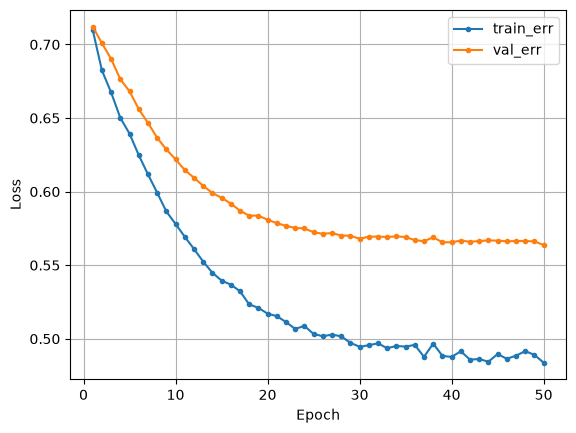

In [ ]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)
# 예측값 범위(0~1) 원래 답(0,1)인데 오차 0.5면 큰 값.

In [18]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(pred.cpu().numpy()[:5])

[[0.19059221]
 [0.7277977 ]
 [0.7082585 ]
 [0.1746636 ]
 [0.57124454]]


In [ ]:
pred = np.where(pred.cpu().numpy() > .5, 1, 0)  # True면 1, False면 0
print(pred[:5])

[[0]
 [1]
 [1]
 [0]
 [1]]


In [ ]:
print(confusion_matrix(y_val_ts.numpy(), pred)) # 원래답(y_val_ts.numpy()), 예측값(pred)

[[98 22]
 [35 59]]


In [22]:
print(classification_report(y_val_ts.numpy(), pred))

              precision    recall  f1-score   support

         0.0       0.74      0.82      0.77       120
         1.0       0.73      0.63      0.67        94

    accuracy                           0.73       214
   macro avg       0.73      0.72      0.72       214
weighted avg       0.73      0.73      0.73       214



In [29]:
# 이진 분류: 은닉층 추가
# 모델링에서 불필요한 열 제거
data = data.drop(['PassengerId', 'Name'], axis = 1)


# x, y분할
target = 'Survived'
x = data.drop(target, axis =1)
y = data.loc[:, target]


# 가변수화
x = pd.get_dummies(x, columns = ['Pclass', 'Sex', 'Embarked'], drop_first = True)


# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일러 선언
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values
train_loader, x_val_ts, y_val_ts = make_DataLoader(x_train, x_val, y_train, y_val, 32)


In [39]:
# 모델 구조: 은닉층 추가
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential(nn.Linear(n_feature, 50),      # w 35개가 됨. output 늘리면 행렬을 분해하겠다는 뜻. 분해해서 분석한다는 의미.
            nn.ReLU(),
            nn.Linear(50, 5),    # 아웃풋 1개면 sigmoid -> BCE. 아웃풋이 2개 이상이면 softmax -> CE여야
            nn.ReLU(),
            nn.Linear(5,1),
            nn.Sigmoid()
            ).to(device)


loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)



In [40]:
model

# in_features=7은 데이터 들어오는 컬럼 수. 내가 선택할 수 x
# out_features=1은 이진분류, 다중분류에 따라 결정해야. 내가 선택할 수 x
# bias=True니까 w가 더 붙음. 5개쪽 + 1개쪽에. so, w는 46개.


Sequential(
  (0): Linear(in_features=7, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=5, bias=True)
  (3): ReLU()
  (4): Linear(in_features=5, out_features=1, bias=True)
  (5): Sigmoid()
)

In [41]:
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.619338, val loss : 0.551714
Epoch 2, train loss : 0.492034, val loss : 0.495833
Epoch 3, train loss : 0.463097, val loss : 0.470194
Epoch 4, train loss : 0.440477, val loss : 0.455384
Epoch 5, train loss : 0.438985, val loss : 0.473082
Epoch 6, train loss : 0.454968, val loss : 0.451234
Epoch 7, train loss : 0.445285, val loss : 0.447529
Epoch 8, train loss : 0.435690, val loss : 0.458213
Epoch 9, train loss : 0.427982, val loss : 0.441655
Epoch 10, train loss : 0.427145, val loss : 0.439373
Epoch 11, train loss : 0.424352, val loss : 0.448629
Epoch 12, train loss : 0.425615, val loss : 0.446787
Epoch 13, train loss : 0.429707, val loss : 0.463840
Epoch 14, train loss : 0.420232, val loss : 0.486292
Epoch 15, train loss : 0.437436, val loss : 0.467016
Epoch 16, train loss : 0.430423, val loss : 0.439740
Epoch 17, train loss : 0.406157, val loss : 0.437938
Epoch 18, train loss : 0.410910, val loss : 0.436080
Epoch 19, train loss : 0.406740, val loss : 0.435298
Ep

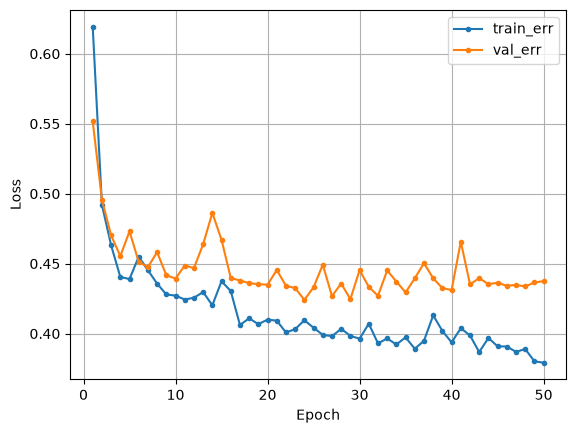

In [42]:
dl_learning_curve(tr_loss_list, val_loss_list)

In [44]:
# 직원 이직 예측
path = 'https://bit.ly/attri_csv'
data = pd.read_csv(path)
data.head()


,Attrition,Age,Department,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany
0,0,33,Research & Development,7,3,817,3,Male,3,Married,11691,0,No,11,0,14,3,4,13
1,0,35,Research & Development,18,2,1412,3,Male,4,Single,9362,2,No,11,0,10,2,3,2
2,0,42,Research & Development,6,3,1911,3,Male,1,Married,13348,9,No,13,1,18,3,4,13
3,0,46,Sales,2,3,1204,3,Female,1,Married,17048,8,No,23,0,28,2,3,26
4,1,22,Research & Development,4,1,593,3,Male,3,Single,3894,5,No,16,0,4,3,3,2


In [45]:
target = 'Attrition'
x = data.drop([target, 'EmployeeNumber'], axis = 1)
y = data.loc[:, target]
print(x.shape)


(1175, 17)


In [46]:
cat_cols = ['Department', 'Education', 'EnvironmentSatisfaction', 'Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'WorkLifeBalance']
x = pd.get_dummies(x, columns = cat_cols, drop_first=True)
x.shape


(1175, 28)

In [47]:
# train, val 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val을 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


In [49]:
train_loader, x_val_ts, y_val_ts = make_DataLoader(x_train, x_val, y_train, y_val, 32)

In [50]:
from torchsummary import summary
n_feature = x.shape[1]
model = nn.Sequential(nn.Linear(n_feature, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
            ).to(device)
summary(model, input_size=(n_feature,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 16]             464
              ReLU-2                   [-1, 16]               0
            Linear-3                    [-1, 8]             136
              ReLU-4                    [-1, 8]               0
            Linear-5                    [-1, 1]               9
           Sigmoid-6                    [-1, 1]               0
Total params: 609
Trainable params: 609
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [51]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.001)


In [52]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.662653, val loss : 0.619538
Epoch 2, train loss : 0.580058, val loss : 0.532906
Epoch 3, train loss : 0.497643, val loss : 0.461908
Epoch 4, train loss : 0.448442, val loss : 0.432018
Epoch 5, train loss : 0.429663, val loss : 0.424720
Epoch 6, train loss : 0.424146, val loss : 0.418924
Epoch 7, train loss : 0.414065, val loss : 0.413489
Epoch 8, train loss : 0.402628, val loss : 0.407543
Epoch 9, train loss : 0.390196, val loss : 0.401716
Epoch 10, train loss : 0.377601, val loss : 0.396196
Epoch 11, train loss : 0.367067, val loss : 0.393564
Epoch 12, train loss : 0.358561, val loss : 0.392088
Epoch 13, train loss : 0.350088, val loss : 0.391122
Epoch 14, train loss : 0.343143, val loss : 0.390456
Epoch 15, train loss : 0.334054, val loss : 0.391678
Epoch 16, train loss : 0.335684, val loss : 0.391979
Epoch 17, train loss : 0.327923, val loss : 0.391364
Epoch 18, train loss : 0.327525, val loss : 0.390703
Epoch 19, train loss : 0.321932, val loss : 0.391025
Ep

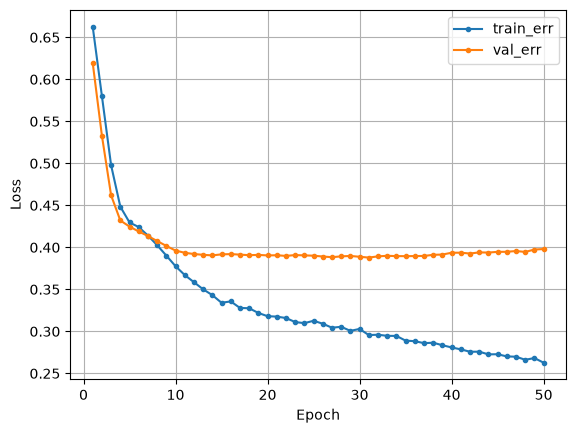

In [56]:
dl_learning_curve(tr_loss_list, val_loss_list)